# Radiative Heating and Vertical-Velocity EOF Cross-Spectral Analysis

This notebook reproduces `Qr_omega.ipynb`. Shared processing uses `src/cross_spectrum_ana.py`; the omega EOF calculation and two-panel figure remain visible because they are analysis-specific.

In [28]:
import os
import sys

CPU_THREADS = 4
for thread_variable in (
    "OMP_NUM_THREADS",
    "OPENBLAS_NUM_THREADS",
    "MKL_NUM_THREADS",
    "BLIS_NUM_THREADS",
    "NUMEXPR_NUM_THREADS",
):
    os.environ[thread_variable] = str(CPU_THREADS)

from pathlib import Path

import netCDF4 as nc
import numpy as np
from matplotlib import pyplot as plt
from threadpoolctl import threadpool_limits

# Also enforce the limit if a numerical library was loaded by the kernel.
THREADPOOL_LIMITER = threadpool_limits(limits=CPU_THREADS)

sys.path.append("/home/b11209013/Manuscript_Prep/KW_CRI/src")
import cross_spectrum_ana as workflow

## 1. Helpers and configuration

In [29]:
def as_float_array(values: np.ndarray) -> np.ndarray:
    masked_values = np.ma.asarray(values, dtype=np.float64)
    return np.asarray(masked_values.filled(np.nan))


def calculate_eof(data: np.ndarray, n_components: int) -> tuple[np.ndarray, np.ndarray]:
    """Reproduce the EOF/PC calculation used in the original notebook."""
    _, n_samples = data.shape
    anomalies = data - np.nanmean(data, axis=1, keepdims=True)
    covariance = (anomalies @ anomalies.T) / n_samples
    _, eigenvectors = np.linalg.eig(covariance)
    eofs = eigenvectors[:, :n_components]
    eofs = eofs / np.sum(eofs, axis=0)
    pcs = np.linalg.inv(eofs.T @ eofs) @ (eofs.T @ anomalies)
    return eofs, pcs

DATA_PATH = Path("/data92/b11209013")
OUTPUT_PATH = Path("/home/b11209013/Manuscript_Prep/KW_CRI/Figure/Qr_W")
LATITUDE_BOUNDS = (-5.0, 5.0)
WINDOW_SIZE = 96
OVERLAP_SIZE = WINDOW_SIZE // 2
MERIDIONAL_COMPONENT = "symmetric"
SOURCE_NAME = "SW"
REFERENCE_KEYS = ("W1", "W2")
COHERENCE_LEVELS = (0.5, 0.6, 0.8)
EQUIVALENT_DEPTHS = (8.0, 90.0)

## 2. Load radiative heating and vertical velocity

In [30]:
with nc.Dataset(DATA_PATH / "CERES" / "column_LW_rm3harm.nc") as dataset:
    latitude = as_float_array(dataset.variables["lat"][:])
    longitude = as_float_array(dataset.variables["lon"][:])
    latitude_mask = (latitude >= LATITUDE_BOUNDS[0]) & (latitude <= LATITUDE_BOUNDS[1])
    lw_heating = as_float_array(dataset.variables["column_LW"][:, latitude_mask, :])

with nc.Dataset(DATA_PATH / "CERES" / "column_SW_rm3harm.nc") as dataset:
    sw_heating = as_float_array(dataset.variables["column_SW"][:, latitude_mask, :])

with nc.Dataset(DATA_PATH / "ERA5_GRIB" / "Data" / "regrid" / "W.nc") as dataset:
    w_latitude = as_float_array(dataset.variables["lat"][:])
    w_longitude = as_float_array(dataset.variables["lon"][:])
    w_latitude_mask = (w_latitude >= LATITUDE_BOUNDS[0]) & (w_latitude <= LATITUDE_BOUNDS[1])
    pressure_levels = as_float_array(dataset.variables["plev"][:])
    vertical_velocity = as_float_array(dataset.variables["W"][:, :, w_latitude_mask, :])

n_times, n_levels, n_latitudes, n_longitudes = vertical_velocity.shape
source_fields = {"QR": lw_heating + sw_heating, "LW": lw_heating, "SW": sw_heating}

## 3. Remove means and calculate vertical-velocity EOF modes

The 4-D vertical-velocity anomaly and EOF calculation are kept explicit because they are unique to this analysis.

In [31]:
source_anomalies = {name: workflow.remove_time_zonal_mean(field) for name, field in source_fields.items()}
vertical_velocity_anomaly = vertical_velocity - np.nanmean(
    vertical_velocity, axis=(0, -1), keepdims=True
)

w_eofs, w_pcs = calculate_eof(
    vertical_velocity_anomaly.transpose(1, 0, 2, 3).reshape(n_levels, -1),
    n_components=2,
)
reference_fields = {
    "W1": -w_pcs[0].reshape(n_times, n_latitudes, n_longitudes),
    "W2": -w_pcs[1].reshape(n_times, n_latitudes, n_longitudes),
}

## 4. Select the meridional component and validate each reference

In [32]:
source_components = {
    name: workflow.select_meridional_component(field, MERIDIONAL_COMPONENT)
    for name, field in source_anomalies.items()
}
reference_components = {
    name: workflow.select_meridional_component(field, MERIDIONAL_COMPONENT)
    for name, field in reference_fields.items()
}
for reference in reference_components.values():
    workflow.validate_aligned_fields(source_components, reference)

## 5. Segment all fields once

In [33]:
chunked_fields = workflow.segment_fields(
    {**source_components, **reference_components},
    window_size=WINDOW_SIZE,
    overlap_size=OVERLAP_SIZE,
)
source_chunks = {name: chunked_fields[name] for name in source_components}
n_segments, _, n_latitudes, n_longitudes = chunked_fields["W1"].shape
print(f"Windowed chunk shape: {chunked_fields['W1'].shape}")

Windowed chunk shape: (90, 96, 10, 360)


## 6. Calculate spectra separately for W1 and W2

In [34]:
spectral_results = {}
for reference_name in REFERENCE_KEYS:
    cross, source_power, reference_power = workflow.calculate_segment_spectra(
        source_chunks,
        chunked_fields[reference_name],
        window_size=WINDOW_SIZE,
    )
    mean_cross, mean_source_power, mean_reference_power = workflow.average_segment_spectra(
        cross, source_power, reference_power
    )
    diagnostics = workflow.calculate_spectral_diagnostics(
        mean_cross, mean_source_power, mean_reference_power
    )
    spectral_results[reference_name] = {
        "cross_spectrum": cross,
        "source_power": source_power,
        "reference_power": reference_power,
        "mean_cross_spectrum": mean_cross,
        "mean_source_power": mean_source_power,
        "mean_reference_power": mean_reference_power,
        "diagnostics": diagnostics,
    }

frequencies, zonal_wavenumbers = workflow.spectral_coordinates(WINDOW_SIZE, n_longitudes)

## 7. Prepare W1 and W2 for plotting

In [35]:
plot_data = {}
for reference_name in REFERENCE_KEYS:
    diagnostics = spectral_results[reference_name]["diagnostics"]
    plot_data[reference_name] = workflow.prepare_plot_data(
        frequencies,
        zonal_wavenumbers,
        diagnostics["normalized_cospectrum"][SOURCE_NAME],
        diagnostics["coherence_squared"][SOURCE_NAME],
    )

shifted_wavenumbers, frequency_display, _, _ = plot_data["W1"]

## 8. Generate and save the two-panel figure

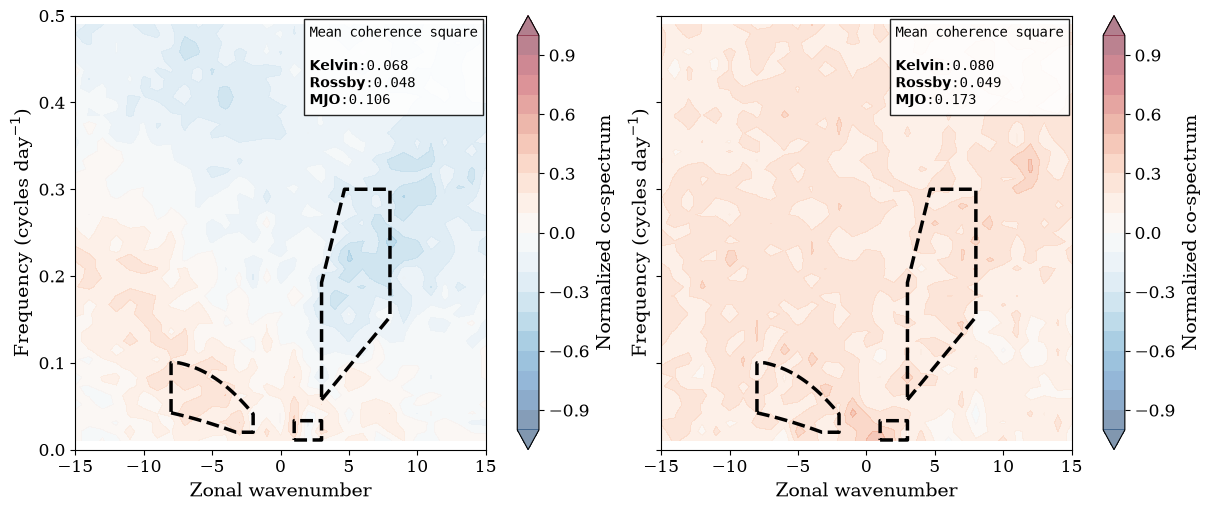

In [36]:
plt.rcParams.update({"font.family": "serif", "font.size": 14, "axes.labelsize": 14, "axes.titlesize": 16, "xtick.labelsize": 12, "ytick.labelsize": 12})
figure, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True, constrained_layout=True)
for axis, reference_name in zip(axes, REFERENCE_KEYS):
    _, axis = workflow.plot_cospectrum_with_coherence(
        *plot_data[reference_name],
        source_name=SOURCE_NAME,
        reference_name=reference_name,
        shading_levels=np.linspace(-1.0, 1.0, 21),
        coherence_levels=COHERENCE_LEVELS,
        equivalent_depths=EQUIVALENT_DEPTHS,
        cmap="RdBu_r",
        extend="both",
        colorbar_label="Normalized co-spectrum",
        axis=axis,
    )
axes[0].set_ylabel("Frequency (cycles day$^{-1}$)")
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
figure.savefig(OUTPUT_PATH / f"{SOURCE_NAME}.png", dpi=600, bbox_inches="tight")
plt.show()